In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(df.shape)      # how many rows & columns?
df.head()            # show first 5 rows

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype)  # should now say float64

float64


In [ ]:
print(df['TotalCharges'].isnull().sum())  # should print 11

11


In [ ]:
df.dropna(subset=['TotalCharges'], inplace=True)
print(df.shape)  # should now be (7032, 21)

(7032, 21)


In [ ]:
df.drop(columns=['customerID'], inplace=True)
print(df.shape)  # should now be (7032, 20)

(7032, 20)


In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

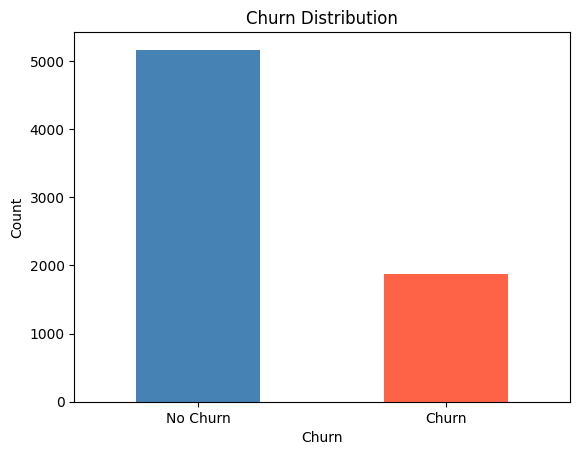

In [ ]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.xticks([0, 1], ['No Churn', 'Churn'], rotation=0)
plt.ylabel('Count')
plt.show()

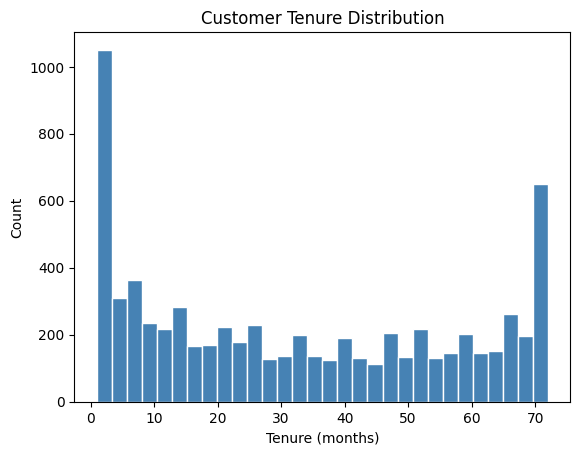

In [ ]:
plt.hist(df['tenure'], bins=30, color='steelblue', edgecolor='white')
plt.title('Customer Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()

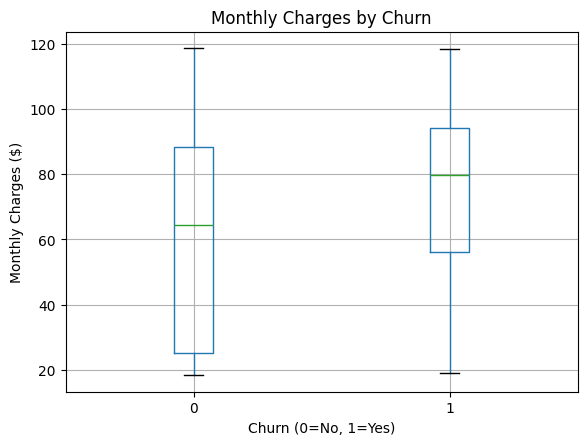

In [ ]:
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly Charges by Churn')
plt.suptitle('')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Monthly Charges ($)')
plt.show()

In [ ]:
X = df.drop(columns=['Churn'])  # everything except Churn
y = df['Churn']                 # only the Churn column

print('X shape:', X.shape)  # should be (7032, 19)
print('y shape:', y.shape)  # should be (7032,)

X shape: (7032, 19)
y shape: (7032,)


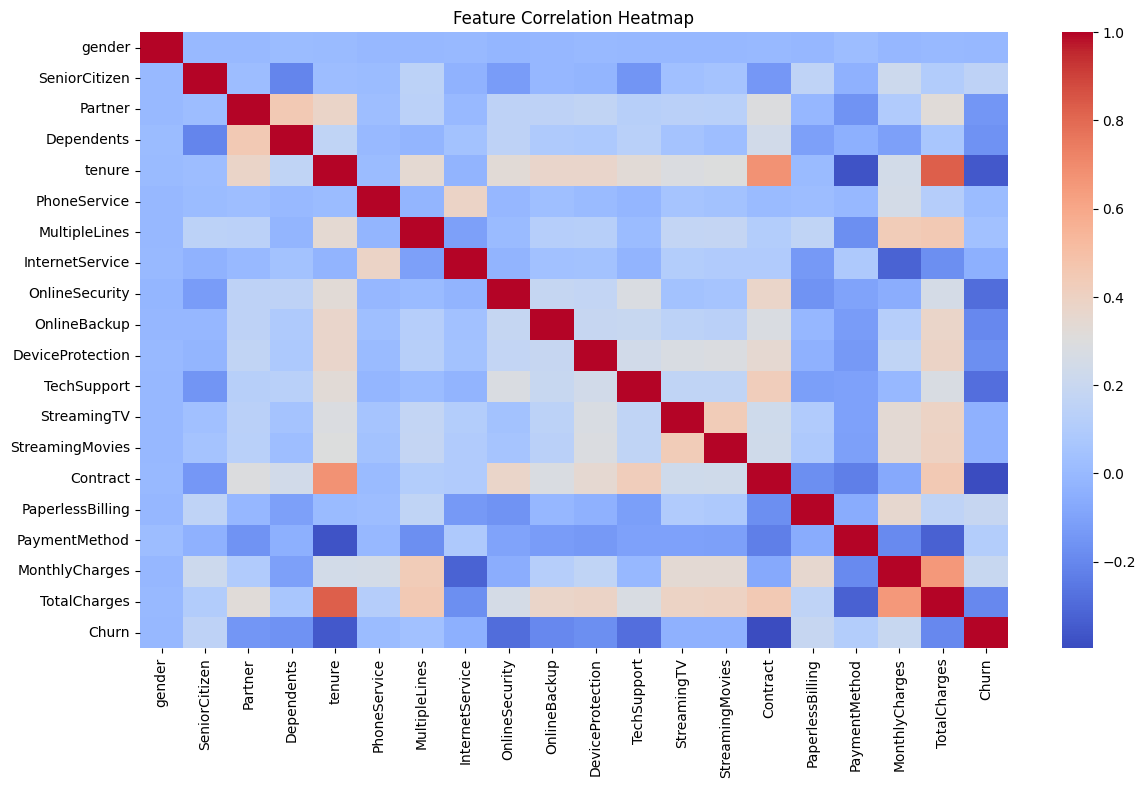

In [ ]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # fixes randomness so results are reproducible
    stratify=y            # keeps same 26/74 churn ratio in both sets
)

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (5625, 19)
Test size:  (1407, 19)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn + apply on train
X_test_scaled  = scaler.transform(X_test)       # only apply on test

print('Scaling done!')

Scaling done!


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

print('Model trained!')

Model trained!


In [ ]:
y_pred_lr  = lr.predict(X_test_scaled)        # predicts 0 or 1
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]  # predicts probability (0.0 to 1.0)

print('Sample predictions:', y_pred_lr[:10])
print('Sample probabilities:', y_proba_lr[:10].round(2))

Sample predictions: [0 1 0 0 0 0 0 0 1 0]
Sample probabilities: [0.02 0.6  0.   0.22 0.1  0.46 0.03 0.18 0.63 0.02]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # Note: no scaling needed for Random Forest!

print('Random Forest trained!')

Random Forest trained!


In [ ]:
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Sample predictions:', y_pred_rf[:10])
print('Sample probabilities:', y_proba_rf[:10].round(2))

Sample predictions: [0 1 0 0 0 0 0 0 1 0]
Sample probabilities: [0.   0.77 0.01 0.03 0.1  0.28 0.04 0.26 0.59 0.01]


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_val_score(lr, scaler.transform(X), y, cv=cv, scoring='roc_auc')
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print(f'Logistic Regression CV ROC-AUC: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}')
print(f'Random Forest       CV ROC-AUC: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}')

Logistic Regression CV ROC-AUC: 0.8443 ± 0.0014
Random Forest       CV ROC-AUC: 0.8241 ± 0.0041


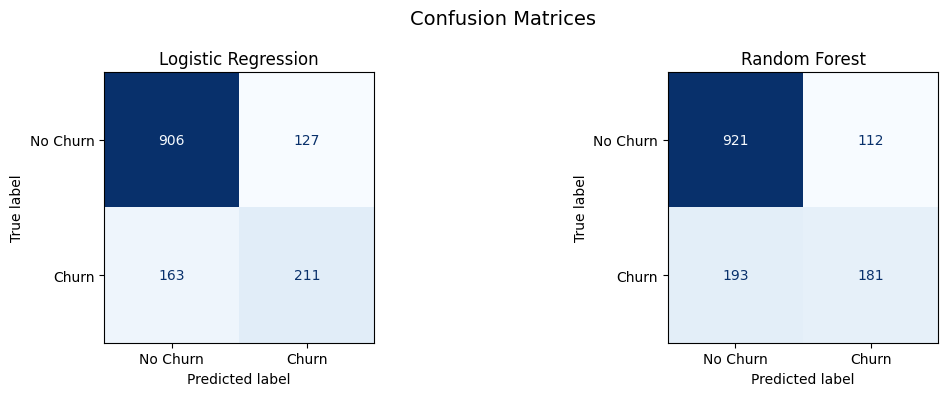

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

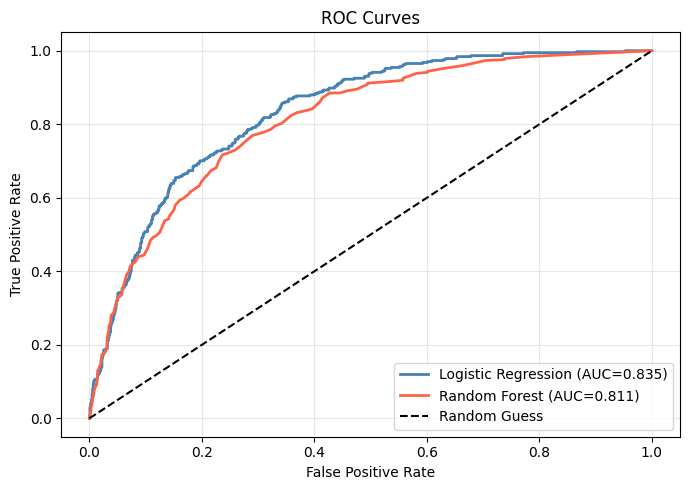

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 5))

for y_proba, label, color in [
    (y_proba_lr, 'Logistic Regression', 'steelblue'),
    (y_proba_rf, 'Random Forest', 'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', lw=2, color=color)

ax.plot([0,1], [0,1], 'k--', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

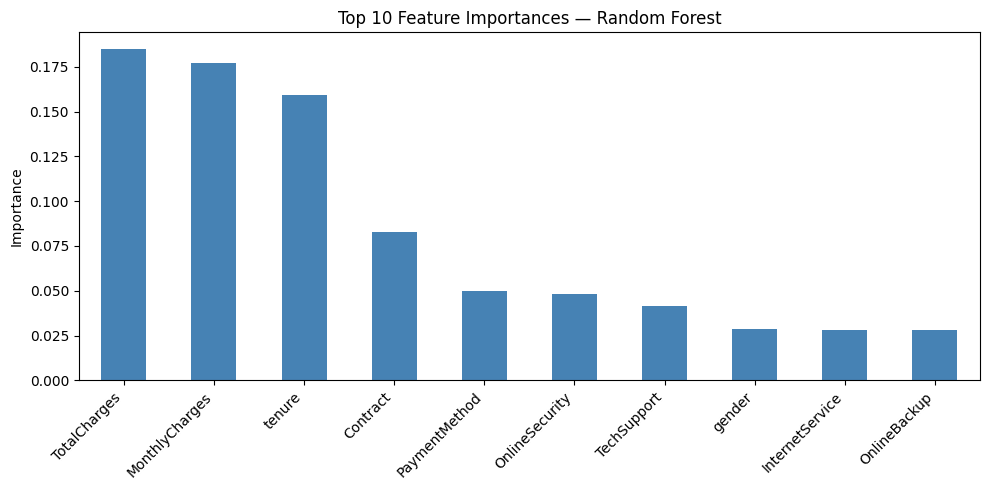

In [ ]:
import numpy as np

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Top 10 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(lr, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print('Saved: churn_model.pkl')
print('Saved: scaler.pkl')
print('Saved: feature_names.pkl')

Saved: churn_model.pkl
Saved: scaler.pkl
Saved: feature_names.pkl


In [ ]:
loaded_model = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Test prediction
test_pred = loaded_model.predict(loaded_scaler.transform(X_test[:5]))
print('Test predictions from loaded model:', test_pred)

Test predictions from loaded model: [0 1 0 0 0]


In [ ]:
from google.colab import files

files.download('churn_model.pkl')
files.download('scaler.pkl')
files.download('feature_names.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('Done! All columns are now numeric.')

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Done! All columns are now numeric.
